# Fase 3: modelos de clasificación supervisada

**Curso:** MCDI504 - Machine Learning I  
**Grupo:** Grupo 5  
**Dataset:** Titanic (`seaborn`)  

## Objetivo

Construir y comparar modelos de clasificación supervisada para predecir si un pasajero sobrevivió al Titanic (`survived`). Se evaluarán KNN, árbol de decisión, SVM, Naive Bayes y redes neuronales multicapa.

La comparación no se basará únicamente en *accuracy*. También se utilizarán precisión, recall, F1-score y matrices de confusión, debido a que las clases no están perfectamente balanceadas.

## 1. Importación de librerías y configuración

Se fija una semilla para favorecer la reproducibilidad. Las advertencias no se ocultan: si un modelo presenta problemas de convergencia, deben analizarse en lugar de ignorarse.

In [1]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="deep")
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Carga y comprensión del conjunto de datos

Cada fila representa a un pasajero. La variable objetivo `survived` tiene dos clases: `0` indica que el pasajero no sobrevivió y `1` que sí sobrevivió.

Se utiliza el dataset proporcionado por `seaborn`, manteniendo la misma fuente del código base entregado por el profesor.

In [2]:
titanic = sns.load_dataset("titanic")

print(f"Dimensiones iniciales: {titanic.shape[0]} filas y {titanic.shape[1]} columnas")
display(titanic.head())

resumen = pd.DataFrame({
    "tipo": titanic.dtypes.astype(str),
    "faltantes": titanic.isna().sum(),
    "porcentaje_faltante": (titanic.isna().mean() * 100).round(2),
    "valores_unicos": titanic.nunique(),
})
display(resumen)

Dimensiones iniciales: 891 filas y 15 columnas


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


,tipo,faltantes,porcentaje_faltante,valores_unicos
survived,int64,0,0.00,2
pclass,int64,0,0.00,3
sex,str,0,0.00,2
age,float64,177,19.87,88
sibsp,int64,0,0.00,7
parch,int64,0,0.00,7
fare,float64,0,0.00,248
embarked,str,2,0.22,3
class,category,0,0.00,3
who,str,0,0.00,3


## 3. Análisis exploratorio inicial

### 3.1 Distribución de la variable objetivo

Antes de entrenar los modelos se revisa el balance de clases. Una diferencia entre las frecuencias justifica complementar el accuracy con métricas específicas para la clase positiva.

,frecuencia,porcentaje
No sobrevivió (0),549,61.62
Sobrevivió (1),342,38.38


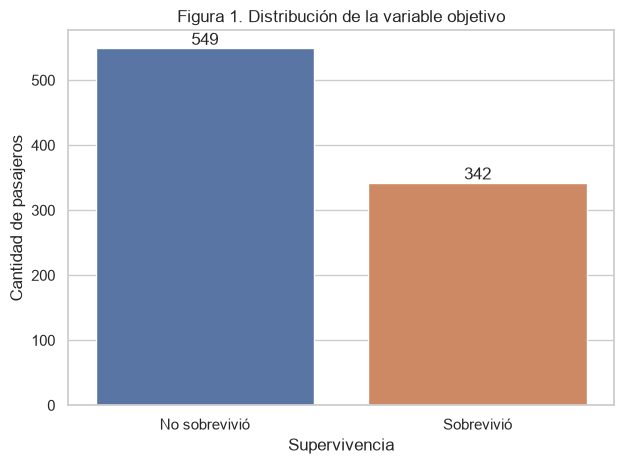

In [3]:
distribucion_clases = titanic["survived"].value_counts().sort_index().to_frame("frecuencia")
distribucion_clases["porcentaje"] = (
    distribucion_clases["frecuencia"] / len(titanic) * 100
).round(2)
distribucion_clases.index = ["No sobrevivió (0)", "Sobrevivió (1)"]
display(distribucion_clases)

ax = sns.countplot(data=titanic, x="survived", hue="survived", legend=False)
ax.set(title="Figura 1. Distribución de la variable objetivo", xlabel="Supervivencia", ylabel="Cantidad de pasajeros")
ax.set_xticks([0, 1], ["No sobrevivió", "Sobrevivió"])
for container in ax.containers:
    ax.bar_label(container)
plt.tight_layout()
plt.show()

### 3.2 Valores faltantes y patrones preliminares

`deck` posee demasiados valores faltantes y no se utilizará. También se eliminan variables redundantes o derivadas directamente de la respuesta, como `alive`, porque producirían fuga de información. Se conservan predictores disponibles antes de conocer el resultado del viaje.

,valores_faltantes
deck,688
age,177
embarked,2
embark_town,2


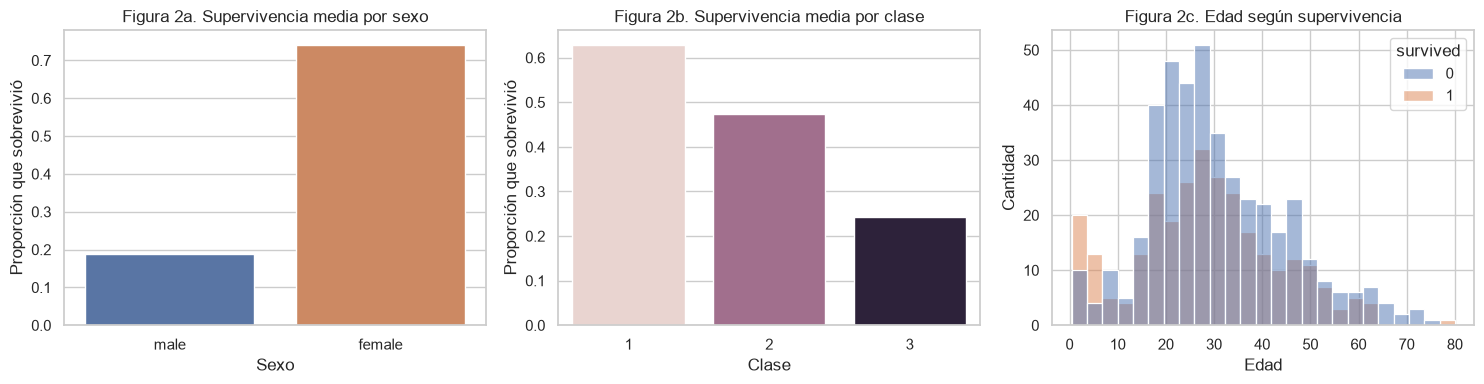

In [4]:
faltantes = titanic.isna().sum().sort_values(ascending=False)
faltantes = faltantes[faltantes > 0]
display(faltantes.to_frame("valores_faltantes"))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(data=titanic, x="sex", y="survived", hue="sex", legend=False, estimator="mean", errorbar=None, ax=axes[0])
axes[0].set(title="Figura 2a. Supervivencia media por sexo", xlabel="Sexo", ylabel="Proporción que sobrevivió")
sns.barplot(data=titanic, x="pclass", y="survived", hue="pclass", legend=False, estimator="mean", errorbar=None, ax=axes[1])
axes[1].set(title="Figura 2b. Supervivencia media por clase", xlabel="Clase", ylabel="Proporción que sobrevivió")
sns.histplot(data=titanic, x="age", hue="survived", bins=25, multiple="layer", ax=axes[2])
axes[2].set(title="Figura 2c. Edad según supervivencia", xlabel="Edad", ylabel="Cantidad")
plt.tight_layout()
plt.show()

## 4. Selección de variables y partición de datos

Se conservan los predictores definidos en el código fuente: `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare` y `embarked`.

- `age` se imputa con la mediana porque esta medida es menos sensible a valores extremos.
- `embarked` se imputa con la categoría más frecuente.
- Las variables categóricas se transforman mediante *one-hot encoding*.
- Se reserva 20% de las observaciones para prueba.
- Se utiliza `random_state=42` para obtener una partición reproducible.

Estas decisiones mantienen la estructura y los parámetros del código fuente entregado.

In [5]:
titanic_processed = titanic.copy()
columns_to_drop = ["deck", "class", "who", "adult_male", "embark_town", "alive", "alone"]
titanic_processed = titanic_processed.drop(columns=columns_to_drop)

titanic_processed["age"] = titanic_processed["age"].fillna(titanic_processed["age"].median())
titanic_processed["embarked"] = titanic_processed["embarked"].fillna(titanic_processed["embarked"].mode()[0])
titanic_processed = pd.get_dummies(titanic_processed, columns=["sex", "embarked"], drop_first=True)

print("Dimensiones procesadas:", titanic_processed.shape)
print("Valores faltantes restantes:", int(titanic_processed.isna().sum().sum()))
display(titanic_processed.head())

Dimensiones procesadas: (891, 9)
Valores faltantes restantes: 0


,survived,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [6]:
X = titanic_processed.drop("survived", axis=1)
y = titanic_processed["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

print("Entrenamiento:", X_train.shape, "| Prueba:", X_test.shape)
print("Proporción de sobrevivientes en entrenamiento:", round(y_train.mean(), 4))
print("Proporción de sobrevivientes en prueba:", round(y_test.mean(), 4))

Entrenamiento: (712, 8) | Prueba: (179, 8)
Proporción de sobrevivientes en entrenamiento: 0.3764
Proporción de sobrevivientes en prueba: 0.4134


## 5. Modelos de clasificación

Todos los modelos utilizan exactamente la misma partición. Para respetar el código fuente, el escalamiento se aplica solamente a SVM y a las redes neuronales. KNN, árbol de decisión y Naive Bayes se entrenan con las variables procesadas sin estandarización adicional.

In [7]:
models = {
    "KNN": Pipeline([
        ("classifier", KNeighborsClassifier(n_neighbors=5, metric="minkowski", p=2)),
    ]),
    "Árbol de decisión": Pipeline([
        ("classifier", DecisionTreeClassifier(max_depth=5, criterion="gini", random_state=RANDOM_STATE)),
    ]),
    "Naive Bayes": Pipeline([
        ("classifier", GaussianNB()),
    ]),
}

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaled_models = {
    "SVM": SVC(kernel="rbf", C=1.0, random_state=RANDOM_STATE),
    "MLP - 1 capa": Pipeline([
        ("classifier", MLPClassifier(hidden_layer_sizes=(100,), activation="relu", solver="adam", max_iter=500, random_state=RANDOM_STATE)),
    ]),
    "MLP - 2 capas": Pipeline([
        ("classifier", MLPClassifier(hidden_layer_sizes=(100, 50), activation="relu", solver="adam", max_iter=500, random_state=RANDOM_STATE)),
    ]),
    "MLP - 3 capas": Pipeline([
        ("classifier", MLPClassifier(hidden_layer_sizes=(100, 50, 25), activation="relu", solver="adam", max_iter=500, random_state=RANDOM_STATE)),
    ]),
}

print("Modelos sin escalamiento:", ", ".join(models.keys()))
print("Modelos con escalamiento:", ", ".join(scaled_models.keys()))

Modelos sin escalamiento: KNN, Árbol de decisión, Naive Bayes
Modelos con escalamiento: SVM, MLP - 1 capa, MLP - 2 capas, MLP - 3 capas


## 6. Entrenamiento y evaluación

La clase positiva corresponde a `sobrevivió = 1`. Por ello, el recall indica qué proporción de los sobrevivientes reales fue identificada correctamente, mientras que la precisión indica qué proporción de las predicciones de supervivencia fue correcta.

In [8]:
results = []
predictions = {}
confusion_matrices = {}
reports = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    predictions[name] = y_pred
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)
    reports[name] = classification_report(
        y_test,
        y_pred,
        target_names=["No sobrevivió", "Sobrevivió"],
        output_dict=True,
        zero_division=0,
    )
    results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
    })

for name, model in scaled_models.items():
    with warnings.catch_warnings(record=True) as captured_warnings:
        warnings.simplefilter("always")
        model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    predictions[name] = y_pred
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)
    reports[name] = classification_report(
        y_test, y_pred,
        target_names=["No sobrevivió", "Sobrevivió"],
        output_dict=True,
        zero_division=0,
    )
    results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
    })
    if captured_warnings:
        print(f"Advertencia metodológica en {name}: el optimizador alcanzó el máximo de iteraciones.")

results_df = pd.DataFrame(results).sort_values("F1-score", ascending=False).reset_index(drop=True)
display(results_df.style.format({c: "{:.4f}" for c in ["Accuracy", "Precision", "Recall", "F1-score"]}))

Advertencia metodológica en MLP - 1 capa: el optimizador alcanzó el máximo de iteraciones.
Advertencia metodológica en MLP - 2 capas: el optimizador alcanzó el máximo de iteraciones.


,Modelo,Accuracy,Precision,Recall,F1-score
0,MLP - 3 capas,0.8268,0.8116,0.7568,0.7832
1,MLP - 1 capa,0.8212,0.8182,0.7297,0.7714
2,SVM,0.8212,0.8387,0.7027,0.7647
3,MLP - 2 capas,0.8156,0.8154,0.7162,0.7626
4,Árbol de decisión,0.7989,0.8276,0.6486,0.7273
5,Naive Bayes,0.7709,0.7200,0.7297,0.7248
6,KNN,0.7151,0.7091,0.5270,0.6047


### 6.1 Matrices de confusión

Las matrices permiten distinguir verdaderos negativos, falsos positivos, falsos negativos y verdaderos positivos. Esto es relevante porque dos modelos con accuracy semejante pueden cometer errores de naturaleza distinta.

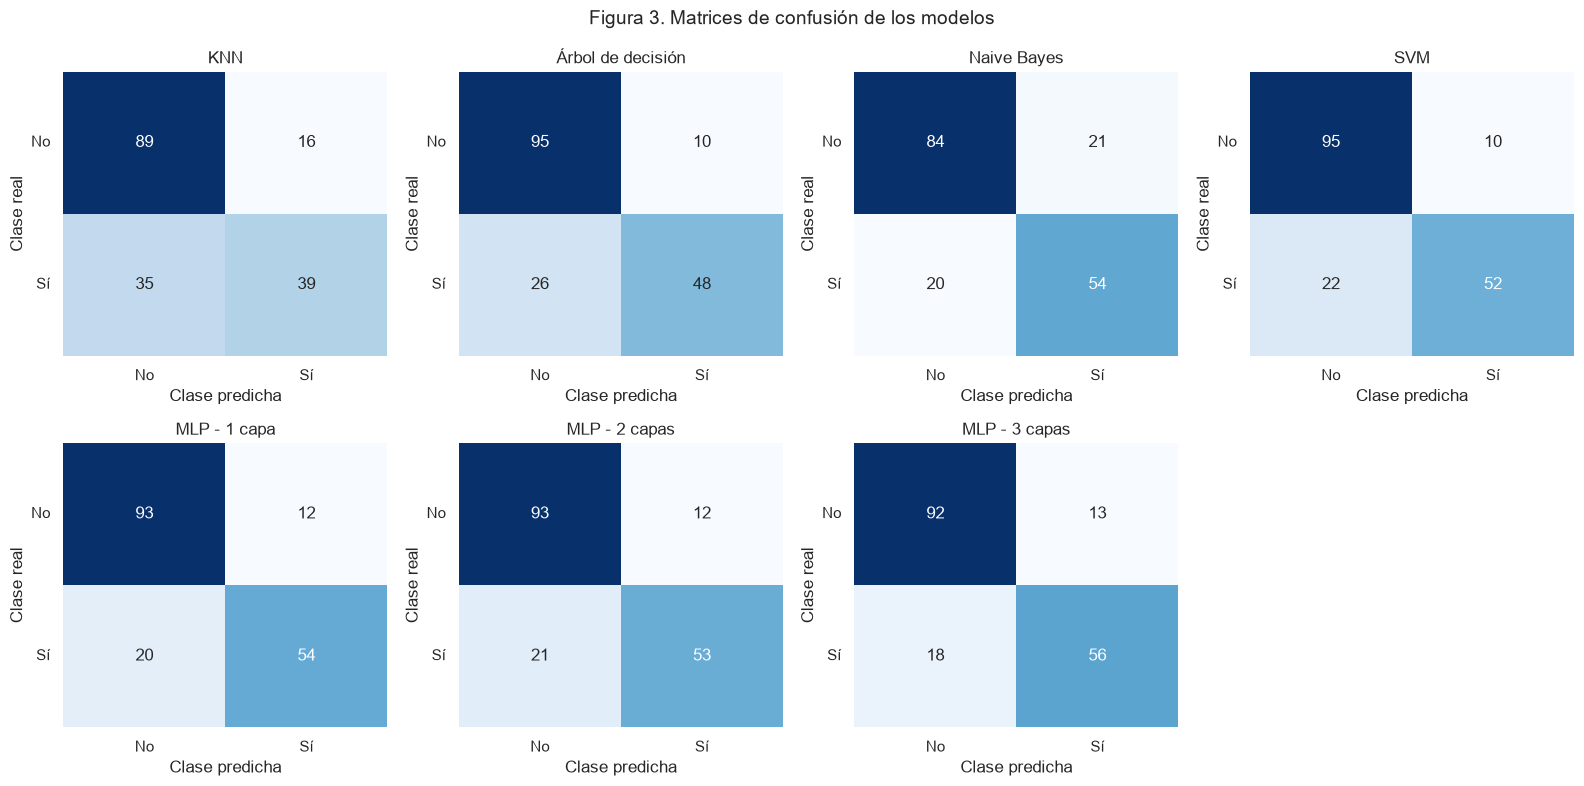

In [9]:
n_models = len(confusion_matrices)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, (name, matrix) in zip(axes, confusion_matrices.items()):
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Clase predicha")
    ax.set_ylabel("Clase real")
    ax.set_xticklabels(["No", "Sí"])
    ax.set_yticklabels(["No", "Sí"], rotation=0)

for ax in axes[n_models:]:
    ax.axis("off")

fig.suptitle("Figura 3. Matrices de confusión de los modelos", fontsize=14)
plt.tight_layout()
plt.show()

### 6.2 Informes de clasificación

Se presenta un informe tabulado para cada modelo. El promedio macro asigna igual importancia a ambas clases; el promedio ponderado considera la frecuencia de cada una.

In [10]:
for name in reports:
    print(f"\n{name}")
    display(pd.DataFrame(reports[name]).T.round(4))


KNN


,precision,recall,f1-score,support
No sobrevivió,0.7177,0.8476,0.7773,105.0000
Sobrevivió,0.7091,0.5270,0.6047,74.0000
accuracy,0.7151,0.7151,0.7151,0.7151
macro avg,0.7134,0.6873,0.6910,179.0000
weighted avg,0.7142,0.7151,0.7059,179.0000



Árbol de decisión


,precision,recall,f1-score,support
No sobrevivió,0.7851,0.9048,0.8407,105.0000
Sobrevivió,0.8276,0.6486,0.7273,74.0000
accuracy,0.7989,0.7989,0.7989,0.7989
macro avg,0.8064,0.7767,0.7840,179.0000
weighted avg,0.8027,0.7989,0.7938,179.0000



Naive Bayes


...

,precision,recall,f1-score,support
No sobrevivió,0.8230,0.8857,0.8532,105.0000
Sobrevivió,0.8182,0.7297,0.7714,74.0000
accuracy,0.8212,0.8212,0.8212,0.8212
macro avg,0.8206,0.8077,0.8123,179.0000
weighted avg,0.8210,0.8212,0.8194,179.0000



MLP - 2 capas


,precision,recall,f1-score,support
No sobrevivió,0.8158,0.8857,0.8493,105.0000
Sobrevivió,0.8154,0.7162,0.7626,74.0000
accuracy,0.8156,0.8156,0.8156,0.8156
macro avg,0.8156,0.8010,0.8060,179.0000
weighted avg,0.8156,0.8156,0.8135,179.0000



MLP - 3 capas


,precision,recall,f1-score,support
No sobrevivió,0.8364,0.8762,0.8558,105.0000
Sobrevivió,0.8116,0.7568,0.7832,74.0000
accuracy,0.8268,0.8268,0.8268,0.8268
macro avg,0.8240,0.8165,0.8195,179.0000
weighted avg,0.8261,0.8268,0.8258,179.0000


## 7. Comparación visual y selección preliminar

La selección preliminar se realiza priorizando F1-score, porque equilibra precisión y recall de la clase positiva. El accuracy se mantiene como medida global complementaria. Esta decisión debe revisarse según el costo real de los falsos positivos y falsos negativos.

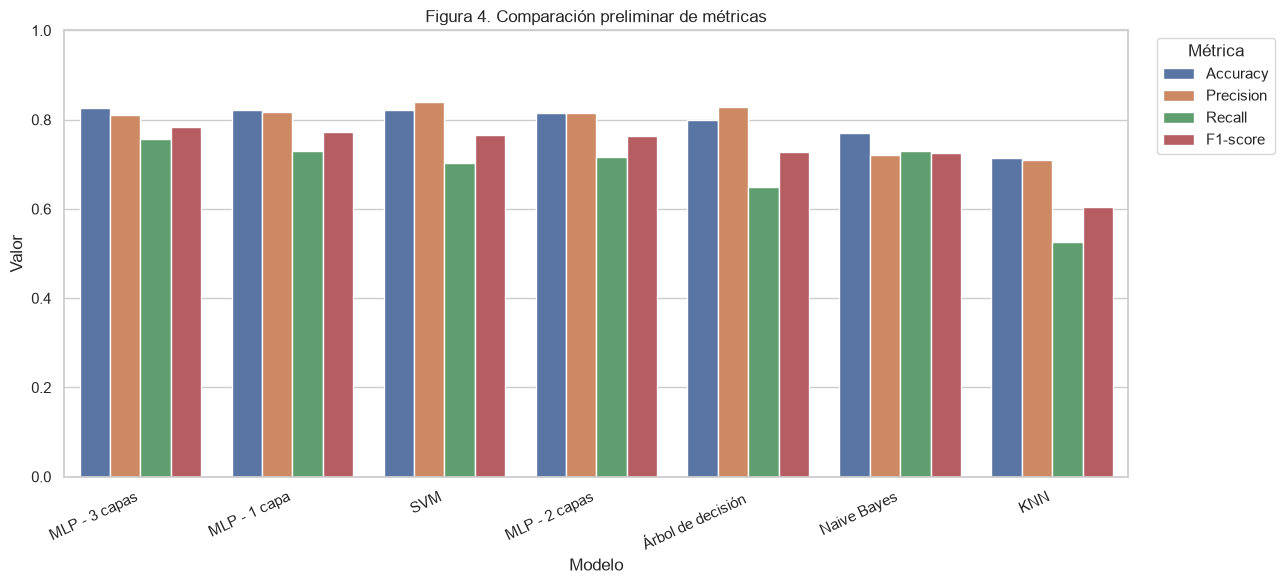

Mejor modelo preliminar según F1-score: MLP - 3 capas
F1-score: 0.7832 | Accuracy: 0.8268


In [11]:
results_long = results_df.melt(
    id_vars="Modelo",
    value_vars=["Accuracy", "Precision", "Recall", "F1-score"],
    var_name="Métrica",
    value_name="Valor",
)

plt.figure(figsize=(13, 6))
ax = sns.barplot(data=results_long, x="Modelo", y="Valor", hue="Métrica")
ax.set(title="Figura 4. Comparación preliminar de métricas", xlabel="Modelo", ylabel="Valor", ylim=(0, 1))
plt.xticks(rotation=25, ha="right")
plt.legend(title="Métrica", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

best_model = results_df.iloc[0]
print(f"Mejor modelo preliminar según F1-score: {best_model['Modelo']}")
print(f"F1-score: {best_model['F1-score']:.4f} | Accuracy: {best_model['Accuracy']:.4f}")

## 8. Interpretación y conclusiones

La tabla anterior constituye la fuente de verdad para el informe: los valores deben copiarse únicamente después de ejecutar todo el notebook en el entorno final.

Para interpretar los resultados:

1. Se compara primero el F1-score y luego el accuracy.
2. Se revisan las matrices de confusión para identificar el tipo de error predominante.
3. Se considera la interpretabilidad: el árbol facilita explicar reglas, mientras que SVM y MLP pueden alcanzar buen desempeño con menor transparencia.
4. Los resultados son preliminares. No se realizó búsqueda exhaustiva de hiperparámetros ni validación cruzada, por lo que todavía no corresponde afirmar que un algoritmo es definitivamente superior.

### Limitaciones

- El dataset representa un caso histórico y contiene variables incompletas.
- La imputación simplifica la incertidumbre asociada a los valores faltantes.
- Una sola partición entrenamiento/prueba puede producir estimaciones variables.
- Las redes neuronales requieren especial atención a convergencia, complejidad e interpretabilidad.

### Trabajo posterior

Se recomienda aplicar validación cruzada, ajustar hiperparámetros y analizar el costo de cada tipo de error antes de seleccionar el modelo final.